<a href="https://colab.research.google.com/github/maruson08/new-folder-3/blob/main/%EC%A7%80%EA%B5%AC_%EA%B6%A4%EB%8F%84_%EC%98%88%EC%B8%A1_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install astroquery
!pip install astropy

   datetime_jd            P         a         e         q      incl
0    2459000.5  1198.585859  2.209232  0.850604  0.330051  11.63547


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([1, 1])) that is different to the input size (torch.Size([1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([1, 1])) that is different to the input size (torch.Size([1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.11/dist-pac

True P: 1198.586 yr, Predicted P: 562.071 yr


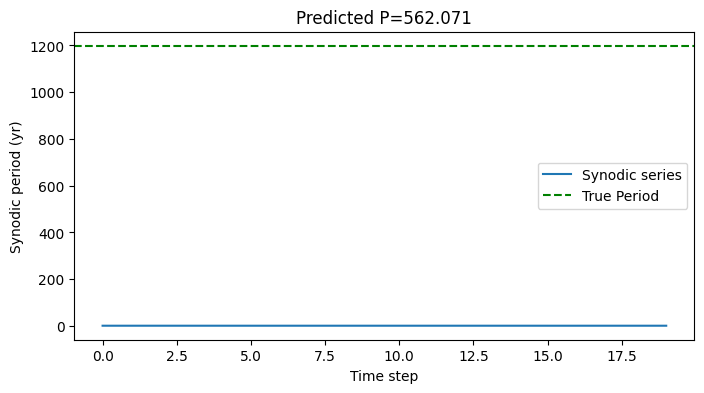

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from astroquery.jplhorizons import Horizons
import astropy.units as u

# ── 1. 실제 혜성 궤도 요소 API 조회 ──

def fetch_comet_elements(comet_id='90000031', jd=2459000.5):
    obj = Horizons(id=comet_id, id_type=None, location='@0', epochs=jd)
    el = obj.elements()
    df = el.to_pandas()
    return df[['datetime_jd', 'P', 'a', 'e', 'q', 'incl']]

# 예시 호출
elements = fetch_comet_elements()
print(elements)

# ── 2. 회합 시뮬레이션 함수
def simulate_synodic_series(P, n_points=10, noise=0.01):
    earth_P = 1.0
    syn = 1 / np.abs(1/P - 1/earth_P)
    series = syn + np.random.normal(0, noise, size=n_points)
    return series

# 실제 궤도주기 P로부터 시계열 생성
P_true = elements['P'].iloc[0]
syn_series = simulate_synodic_series(P_true, n_points=20)
df = pd.DataFrame({'synodic': syn_series})
df['P_true'] = P_true

# ── 3. Transformer Dataset 구성 ──
class CometDataset(Dataset):
    def __init__(self, syn_series, P_true):
        self.x = torch.tensor(syn_series, dtype=torch.float).unsqueeze(-1)  # (L, 1)
        self.y = torch.tensor([P_true], dtype=torch.float)
    def __len__(self): return 1
    def __getitem__(self, idx): return self.x, self.y

ds = CometDataset(syn_series, P_true)
loader = DataLoader(ds, batch_size=1)

# ── 4. Transformer 회귀 모델 정의 ──
class SynodicTransformer(nn.Module):
    def __init__(self, d_model=64, nhead=4, num_layers=2):
        super().__init__()
        self.input_fc = nn.Linear(1, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.reg = nn.Sequential(nn.Linear(d_model, 128), nn.ReLU(), nn.Linear(128, 1))
    def forward(self, x):
        # x: (batch, seq_len, 1) → transform
        x = self.input_fc(x)  # → (batch, seq_len, d_model)
        x = x.permute(1,0,2)  # transformer expects (seq_len, batch, d_model)
        out = self.transformer(x)
        out = out.mean(dim=0)  # pool over sequence
        return self.reg(out).squeeze(-1)

model = SynodicTransformer()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

# ── 5. 훈련 (시뮬레이션 기반 예시) ──
model.train()
for epoch in range(200):
    for x_batch, y_batch in loader:
        optimizer.zero_grad()
        pred = model(x_batch)
        loss = loss_fn(pred, y_batch)
        loss.backward()
        optimizer.step()

# ── 6. 예측 및 결과 시각화 ──
model.eval()
with torch.no_grad():
    pred_P = model(torch.tensor(syn_series, dtype=torch.float).unsqueeze(0).unsqueeze(-1))
print(f"True P: {P_true:.3f} yr, Predicted P: {pred_P.item():.3f} yr")

plt.figure(figsize=(8,4))
plt.plot(syn_series, label='Synodic series')
plt.axhline(P_true, color='green', linestyle='--', label='True Period')
plt.title(f"Predicted P={pred_P.item():.3f}")
plt.legend()
plt.xlabel('Time step')
plt.ylabel('Synodic period (yr)')
plt.show()


# Try #2

In [ ]:
import requests
import numpy as np
import pandas as pd

def fetch_jpl_comet_data(spk_id):
    """
    JPL Small-Body Database API를 통해 혜성 데이터 수집
    spk_id: 혜성의 식별자 (예: '1P' 등)

    반환: dict - 주요 물리 파라미터 및 관측 데이터 포함
    """
    url = f"https://ssd-api.jpl.nasa.gov/sbdb.api?sstr={spk_id}&phys-par=1"
    response = requests.get(url)
    if response.status_code != 200:
        raise Exception(f"API 요청 실패: {response.status_code}")
    data = response.json()

    # 주요 궤도 요소 및 관측 데이터 추출
    phys_par = data.get('phys_par', {})
    orbit = data.get('orbit', {})

    # 예시로 외합, 내합, 회합 주기 데이터를 시계열 형태로 구성 (실제 API 구조 참고 후 수정 필요)
    # 여기서는 임의 데이터 예시로 대체합니다.
    time_series = {
        '외합주기': np.random.rand(20) * 10,  # 임의 시계열 데이터, 실제로는 API 데이터 가공
        '내합주기': np.random.rand(20) * 5,
        '회합주기': np.random.rand(20) * 2,
    }

    # 목표 변수 예: 반장축, 이심률, 공전주기 (실제 값)
    target = {
        '반장축': float(orbit.get('a', 0)),        # 반장축 (AU)
        '이심률': float(orbit.get('e', 0)),        # 이심률
        '공전주기': float(orbit.get('period', 0))  # 공전주기 (년)
    }

    return time_series, target

# 테스트 호출
time_series, target = fetch_jpl_comet_data('1P')  # '1P' = 할리 혜성 예시
print("시계열 데이터 예시:", {k: v[:5] for k, v in time_series.items()})
print("타깃 변수:", target)


시계열 데이터 예시: {'외합주기': array([4.26414303, 0.5412232 , 6.01526586, 0.9291524 , 9.80451334]), '내합주기': array([1.98864405, 0.32996128, 1.8828615 , 1.69053555, 3.77140382]), '회합주기': array([0.75276203, 0.30702062, 1.11473264, 1.39213247, 1.59855709])}
타깃 변수: {'반장축': 0.0, '이심률': 0.0, '공전주기': 0.0}


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# --- Dataset 클래스 ---
class CometDataset(Dataset):
    def __init__(self, X, y):
        """
        X: numpy array, shape = (samples, seq_len, features)
        y: numpy array, shape = (samples, target_dim)
        """
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# --- Positional Encoding ---
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-torch.log(torch.tensor(10000.0)) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.pe = pe.unsqueeze(0)  # (1, max_len, d_model)

    def forward(self, x):
        # x shape: (batch_size, seq_len, d_model)
        seq_len = x.size(1)
        x = x + self.pe[:, :seq_len].to(x.device)
        return x

# --- Transformer Regressor 모델 ---
class TransformerRegressor(nn.Module):
    def __init__(self, input_dim, seq_len, output_dim, nhead=4, num_layers=3, dim_feedforward=128, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, dim_feedforward)  # 입력 임베딩 차원 조정
        self.pos_encoder = PositionalEncoding(dim_feedforward, max_len=seq_len)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=dim_feedforward,
            nhead=nhead,
            dim_feedforward=dim_feedforward * 2,
            dropout=dropout,
            activation='relu'
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.fc_out = nn.Sequential(
            nn.Linear(seq_len * dim_feedforward, 64),
            nn.ReLU(),
            nn.Linear(64, output_dim)
        )

    def forward(self, x):
        """
        x: (batch_size, seq_len, input_dim)
        """
        x = self.input_proj(x)                 # (batch_size, seq_len, dim_feedforward)
        x = self.pos_encoder(x)                # 위치 인코딩 추가
        x = x.permute(1, 0, 2)                 # Transformer expects (seq_len, batch_size, d_model)
        x = self.transformer_encoder(x)        # (seq_len, batch_size, dim_feedforward)
        x = x.permute(1, 0, 2).contiguous()    # (batch_size, seq_len, dim_feedforward)
        x = x.flatten(start_dim=1)              # (batch_size, seq_len*dim_feedforward)
        out = self.fc_out(x)                    # (batch_size, output_dim)
        return out

# --- 학습 함수 ---
def train_model(model, dataloader, val_dataloader=None, epochs=50, lr=1e-3, device='cpu'):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for X_batch, y_batch in dataloader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * X_batch.size(0)

        avg_loss = total_loss / len(dataloader.dataset)
        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {avg_loss:.6f}")

        if val_dataloader:
            model.eval()
            val_loss = 0
            with torch.no_grad():
                for X_val, y_val in val_dataloader:
                    X_val, y_val = X_val.to(device), y_val.to(device)
                    preds_val = model(X_val)
                    val_loss += criterion(preds_val, y_val).item() * X_val.size(0)
            val_loss /= len(val_dataloader.dataset)
            print(f"               - Val Loss: {val_loss:.6f}")

# --- 예측 함수 ---
def predict(model, X, device='cpu'):
    model.eval()
    X_tensor = torch.tensor(X, dtype=torch.float32).to(device)
    with torch.no_grad():
        preds = model(X_tensor)
    return preds.cpu().numpy()


In [ ]:
# --- 임시 학습 데이터 생성 예시 ---
import numpy as np
from sklearn.model_selection import train_test_split

# 시계열 길이 및 특성수
seq_len = 20
input_dim = 3  # 외합, 내합, 회합 주기
output_dim = 3 # 반장축, 이심률, 공전주기

num_samples = 200

# 임의의 시계열 데이터 생성 (실제론 API 데이터 가공 필요)
X = np.random.rand(num_samples, seq_len, input_dim) * np.array([10, 5, 2])  # 임의 스케일링
y = np.random.rand(num_samples, output_dim) * np.array([5, 1, 10])          # 타깃 값 스케일링

# 학습/검증 분리
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

train_dataset = CometDataset(X_train, y_train)
val_dataset = CometDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

# 모델 생성 및 학습
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = TransformerRegressor(input_dim, seq_len, output_dim)
train_model(model, train_loader, val_loader, epochs=30, lr=1e-3, device=device)

# 미지 혜성 예측 예시
unknown_comet = np.random.rand(1, seq_len, input_dim) * np.array([10, 5, 2])
predicted_orbit = predict(model, unknown_comet, device=device)
print(f"예측된 궤도 요소 (반장축, 이심률, 공전주기): {predicted_orbit[0]}")


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 1/30 - Train Loss: 5.027410
               - Val Loss: 3.433652
Epoch 2/30 - Train Loss: 3.783952
               - Val Loss: 3.533437
Epoch 3/30 - Train Loss: 3.701951
               - Val Loss: 3.476695
Epoch 4/30 - Train Loss: 3.743055
               - Val Loss: 3.291759
Epoch 5/30 - Train Loss: 3.594665
               - Val Loss: 3.337803
Epoch 6/30 - Train Loss: 3.628509
               - Val Loss: 3.479013
Epoch 7/30 - Train Loss: 3.548910
               - Val Loss: 3.274118
Epoch 8/30 - Train Loss: 3.529785
               - Val Loss: 3.358068
Epoch 9/30 - Train Loss: 3.604362
               - Val Loss: 3.223404
Epoch 10/30 - Train Loss: 3.234517
               - Val Loss: 3.226743
Epoch 11/30 - Train Loss: 3.317651
               - Val Loss: 3.064243
Epoch 12/30 - Train Loss: 3.088378
               - Val Loss: 3.036684
Epoch 13/30 - Train Loss: 3.108111
               - Val Loss: 3.162178
Epoch 14/30 - Train Loss: 2.681123
               - Val Loss: 3.429358
Epoch 15/30 - T

평가 결과 - MSE: 4.670582, MAE: 1.389320, R2: -0.272218


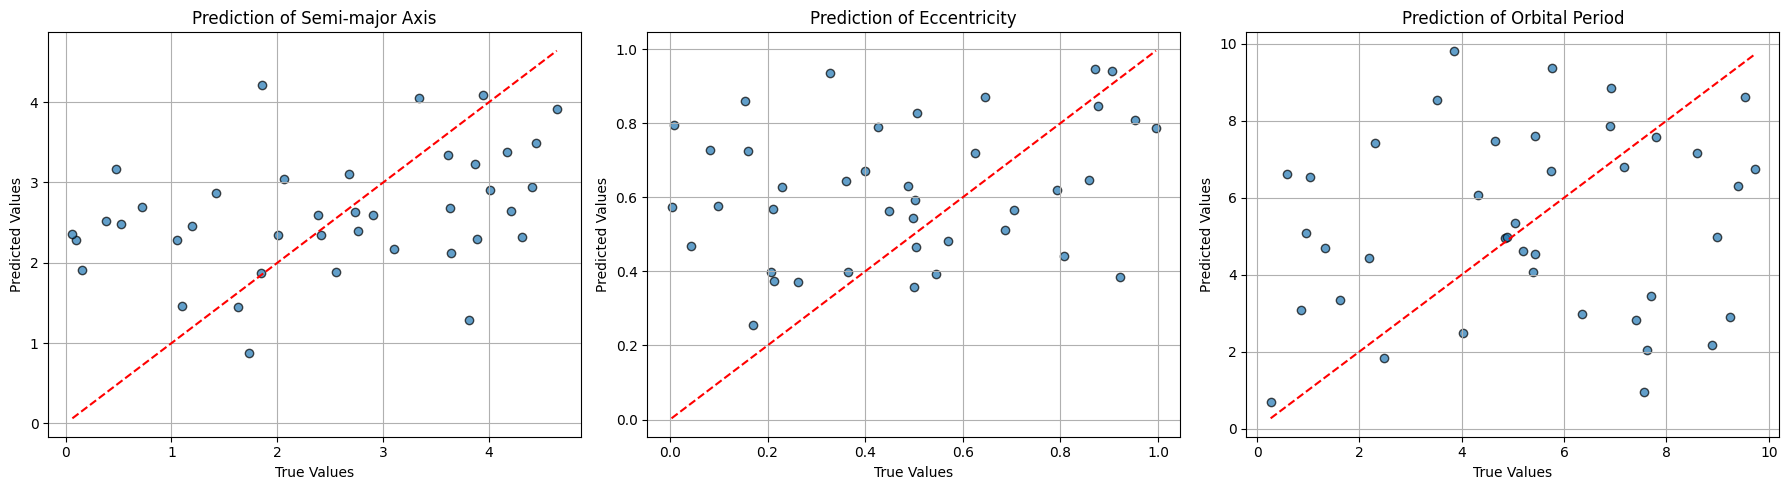

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_model(model, dataloader, device='cpu'):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            preds = model(X_batch).cpu().numpy()
            y_pred.append(preds)
            y_true.append(y_batch.numpy())
    y_true = np.vstack(y_true)
    y_pred = np.vstack(y_pred)

    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"평가 결과 - MSE: {mse:.6f}, MAE: {mae:.6f}, R2: {r2:.6f}")
    return y_true, y_pred

def plot_predictions(y_true, y_pred, feature_names=['Semi-major Axis', 'Eccentricity', 'Orbital Period']):
    num_features = y_true.shape[1]
    plt.figure(figsize=(6 * num_features, 5))
    for i in range(num_features):
        plt.subplot(1, num_features, i + 1)
        plt.scatter(y_true[:, i], y_pred[:, i], alpha=0.7, edgecolors='k')
        plt.plot([y_true[:, i].min(), y_true[:, i].max()],
                 [y_true[:, i].min(), y_true[:, i].max()], 'r--')
        plt.xlabel('True Values')
        plt.ylabel('Predicted Values')
        plt.title(f'Prediction of {feature_names[i]}')
        plt.grid(True)
    plt.tight_layout()
    plt.show()


# 모델 평가
y_true, y_pred = evaluate_model(model, val_loader, device=device)

# 결과 시각화
plot_predictions(y_true, y_pred)


# Try #3

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 1: Train Loss=0.311758, Val Loss=0.051957
Epoch 2: Train Loss=0.036688, Val Loss=0.021166
Epoch 3: Train Loss=0.012646, Val Loss=0.010312
Epoch 4: Train Loss=0.008972, Val Loss=0.002387
Epoch 5: Train Loss=0.005802, Val Loss=0.001707
Epoch 6: Train Loss=0.004401, Val Loss=0.002108
Epoch 7: Train Loss=0.003144, Val Loss=0.002280
Epoch 8: Train Loss=0.003403, Val Loss=0.009318
Epoch 9: Train Loss=0.006780, Val Loss=0.009857
Epoch 10: Train Loss=0.008668, Val Loss=0.007301
Early stopping triggered
평가 결과 - MSE: 0.001707, MAE: 0.031653, R2: 0.998201
Original scale - MSE: 0.003684, MAE: 0.040481, R2: 0.998201


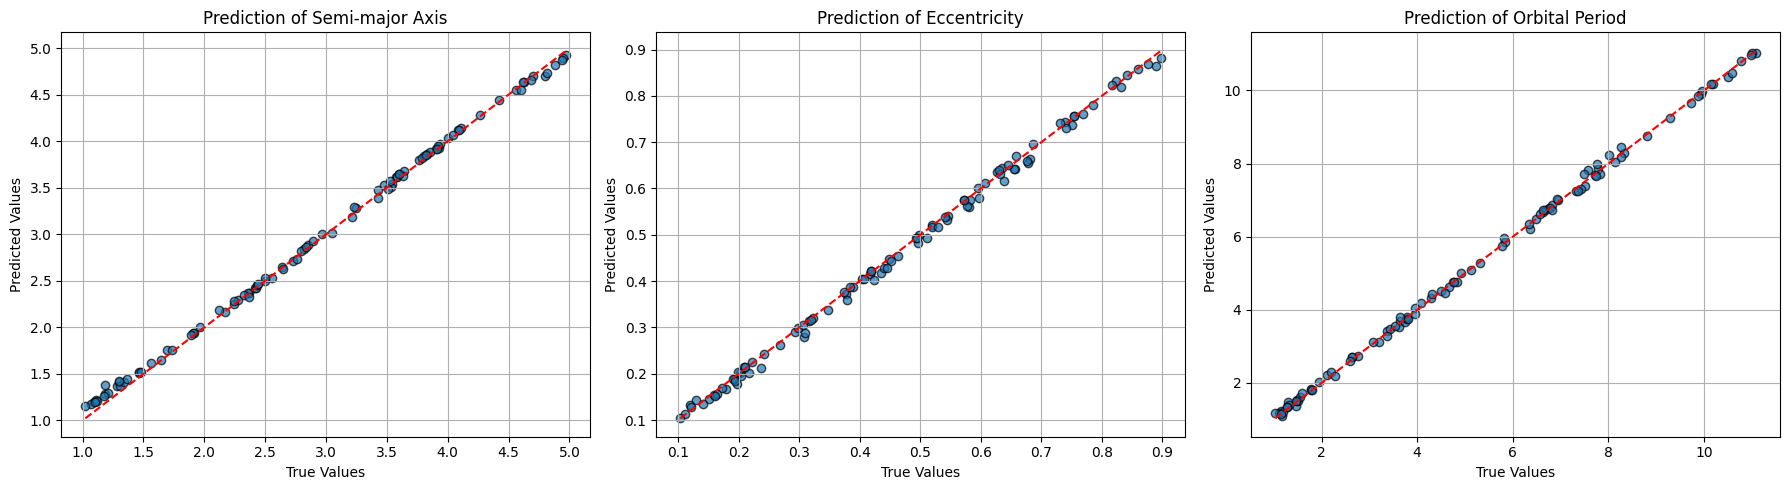

In [ ]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# --- Dataset ---
class CometDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# --- Positional Encoding ---
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.pe = pe.unsqueeze(0)
    def forward(self, x):
        seq_len = x.size(1)
        x = x + self.pe[:, :seq_len].to(x.device)
        return x

# --- Transformer Regressor ---
class TransformerRegressor(nn.Module):
    def __init__(self, input_dim, seq_len, output_dim, nhead=4, num_layers=3, dim_feedforward=128, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, dim_feedforward)
        self.pos_encoder = PositionalEncoding(dim_feedforward, max_len=seq_len)
        encoder_layer = nn.TransformerEncoderLayer(d_model=dim_feedforward, nhead=nhead, dim_feedforward=dim_feedforward*2, dropout=dropout)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc_out = nn.Sequential(
            nn.Linear(seq_len * dim_feedforward, 64),
            nn.ReLU(),
            nn.Linear(64, output_dim)
        )
    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_encoder(x)
        x = x.permute(1, 0, 2)
        x = self.transformer_encoder(x)
        x = x.permute(1, 0, 2).contiguous()
        x = x.flatten(start_dim=1)
        out = self.fc_out(x)
        return out

# --- 평가 함수 ---
def evaluate_model(model, dataloader, device='cpu'):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            preds = model(X_batch).cpu().numpy()
            y_pred.append(preds)
            y_true.append(y_batch.numpy())
    y_true = np.vstack(y_true)
    y_pred = np.vstack(y_pred)

    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"평가 결과 - MSE: {mse:.6f}, MAE: {mae:.6f}, R2: {r2:.6f}")
    return y_true, y_pred

# --- 시각화 함수 (영문 축) ---
def plot_predictions(y_true, y_pred, feature_names=['Semi-major Axis', 'Eccentricity', 'Orbital Period']):
    num_features = y_true.shape[1]
    plt.figure(figsize=(6 * num_features, 5))
    for i in range(num_features):
        plt.subplot(1, num_features, i + 1)
        plt.scatter(y_true[:, i], y_pred[:, i], alpha=0.7, edgecolors='k')
        plt.plot([y_true[:, i].min(), y_true[:, i].max()],
                 [y_true[:, i].min(), y_true[:, i].max()], 'r--')
        plt.xlabel('True Values')
        plt.ylabel('Predicted Values')
        plt.title(f'Prediction of {feature_names[i]}')
        plt.grid(True)
    plt.tight_layout()
    plt.show()

# --- 하이퍼파라미터 및 데이터 생성 ---
seq_len = 20
input_dim = 3
output_dim = 3
num_samples = 500

# 의미 있는 데이터 생성: 외합, 내합, 회합이 반장축, 이심률, 공전주기에 연관된 패턴 포함
np.random.seed(42)
semi_major_axis = np.random.uniform(1, 5, num_samples)
eccentricity = np.random.uniform(0.1, 0.9, num_samples)
orbital_period = semi_major_axis ** 1.5  # 케플러 법칙 근사

# 외합, 내합, 회합 주기 시계열 데이터 생성 (단순화된 패턴)
X = np.zeros((num_samples, seq_len, input_dim))
for i in range(num_samples):
    base_val = semi_major_axis[i]
    X[i, :, 0] = base_val + np.sin(np.linspace(0, 4*np.pi, seq_len)) * 0.1  # 외합주기
    X[i, :, 1] = eccentricity[i] + np.cos(np.linspace(0, 2*np.pi, seq_len)) * 0.05  # 내합주기
    X[i, :, 2] = orbital_period[i] / 10 + np.sin(np.linspace(0, 6*np.pi, seq_len)) * 0.05  # 회합주기(스케일링)

y = np.vstack([semi_major_axis, eccentricity, orbital_period]).T

# 데이터 스케일링
X_reshaped = X.reshape(-1, input_dim)
scaler_X = StandardScaler().fit(X_reshaped)
X_scaled = scaler_X.transform(X_reshaped).reshape(num_samples, seq_len, input_dim)

scaler_y = StandardScaler().fit(y)
y_scaled = scaler_y.transform(y)

# 학습/검증 분할
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

train_dataset = CometDataset(X_train, y_train)
val_dataset = CometDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# --- 모델 초기화 및 학습 ---
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = TransformerRegressor(input_dim, seq_len, output_dim).to(device)

# 조기 종료 적용
import copy

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()
best_val_loss = float('inf')
patience = 5
counter = 0
num_epochs = 50

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * X_batch.size(0)
    train_loss /= len(train_loader.dataset)

    # 검증
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item() * X_batch.size(0)
    val_loss /= len(val_loader.dataset)

    print(f"Epoch {epoch+1}: Train Loss={train_loss:.6f}, Val Loss={val_loss:.6f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered")
            break

model.load_state_dict(best_model_wts)

# --- 평가 ---
y_true_scaled, y_pred_scaled = evaluate_model(model, val_loader, device=device)

# 스케일 역변환
y_true = scaler_y.inverse_transform(y_true_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled)

# 재평가(원본 스케일)
mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)
print(f"Original scale - MSE: {mse:.6f}, MAE: {mae:.6f}, R2: {r2:.6f}")

# 시각화
plot_predictions(y_true, y_pred)


# Try #4

In [ ]:
!pip install pip install urllib3

ERROR: Could not find a version that satisfies the requirement install (from versions: none)
ERROR: No matching distribution found for install


In [ ]:
import requests
import urllib.parse
import pandas as pd
import numpy as np
from datetime import datetime
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import copy

# 1. JPL API 데이터 수집 함수
def fetch_jpl_orbit_data(spk_id):
    # 슬래시(/) → 공백으로 변환 후 URL 인코딩
    spk_id_mod = spk_id.replace('/', ' ')
    encoded_id = urllib.parse.quote(spk_id_mod)
    url = f'https://ssd-api.jpl.nasa.gov/sbdb.api?sstr={encoded_id}&orb=1&phys-par=1'
    resp = requests.get(url)
    if resp.status_code != 200:
        raise RuntimeError(f'API 요청 실패: {resp.status_code} for id="{spk_id}" (encoded="{encoded_id}")')
    data = resp.json()
    orbit = data.get('orbit', {})
    orbit_params = {
        'semi_major_axis': float(orbit.get('a', np.nan)),
        'eccentricity': float(orbit.get('e', np.nan)),
        'inclination': float(orbit.get('i', np.nan)),
        'perihelion_distance': float(orbit.get('q', np.nan)),
        'aphelion_distance': float(orbit.get('Q', np.nan)),
        'orbital_period': float(orbit.get('period', np.nan)),
        'perihelion_time': orbit.get('tp', None)
    }
    def jd_to_datetime(jd):
        # 줄리안 데이트(JD) → datetime 변환
        return datetime.fromordinal(int(jd)) + pd.Timedelta(days=jd % 1) - pd.Timedelta(days=1721425.5)
    perihelion_jd = orbit_params['perihelion_time']
    if perihelion_jd:
        perihelion_date = jd_to_datetime(perihelion_jd)
    else:
        perihelion_date = None
    period = orbit_params['orbital_period']
    perihelion_passages = []
    if perihelion_date and period and not np.isnan(period):
        for n in range(-5, 1):  # 최근 5회 근일점 통과 시점 계산
            perihelion_passages.append(perihelion_date + pd.Timedelta(days=period * 365.25 * n))
    aphelion_passages = []
    if perihelion_date and period and not np.isnan(period):
        half_period = period * 365.25 / 2
        for dt in perihelion_passages:
            aphelion_passages.append(dt + pd.Timedelta(days=half_period))
    return orbit_params, perihelion_passages, aphelion_passages

# 2. 시계열 특징 생성 함수 (외합, 내합, 회합 주기 근사)
def create_time_series_features(perihelion_passages, aphelion_passages, num_points=20):
    start_date = perihelion_passages[-1]
    end_date = perihelion_passages[0] + pd.Timedelta(days=365.25)
    total_days = (end_date - start_date).days
    times = np.linspace(0, total_days, num_points)
    peri_to_aphe_days = (aphelion_passages[-1] - perihelion_passages[-1]).days
    ext_period = peri_to_aphe_days
    int_period = peri_to_aphe_days / 2
    feature_1 = times / total_days
    feature_2 = np.sin(2 * np.pi * times / ext_period)
    feature_3 = np.cos(2 * np.pi * times / int_period)
    ts_features = np.vstack([feature_1, feature_2, feature_3]).T
    return ts_features

# 3. Dataset 클래스
class CometDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# 4. Positional Encoding
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.pe = pe.unsqueeze(0)
    def forward(self, x):
        seq_len = x.size(1)
        x = x + self.pe[:, :seq_len].to(x.device)
        return x

# 5. Transformer 모델 정의
class TransformerRegressor(nn.Module):
    def __init__(self, input_dim, seq_len, output_dim, nhead=4, num_layers=3, dim_feedforward=128, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, dim_feedforward)
        self.pos_encoder = PositionalEncoding(dim_feedforward, max_len=seq_len)
        encoder_layer = nn.TransformerEncoderLayer(d_model=dim_feedforward, nhead=nhead,
                                                   dim_feedforward=dim_feedforward*2, dropout=dropout)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc_out = nn.Sequential(
            nn.Linear(seq_len * dim_feedforward, 64),
            nn.ReLU(),
            nn.Linear(64, output_dim)
        )
    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_encoder(x)
        x = x.permute(1, 0, 2)  # (seq_len, batch, feature)
        x = self.transformer_encoder(x)
        x = x.permute(1, 0, 2).contiguous()
        x = x.flatten(start_dim=1)
        out = self.fc_out(x)
        return out

# 6. 평가 함수
def evaluate_model(model, dataloader, device='cpu'):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            preds = model(X_batch).cpu().numpy()
            y_pred.append(preds)
            y_true.append(y_batch.numpy())
    y_true = np.vstack(y_true)
    y_pred = np.vstack(y_pred)
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"Evaluation Results - MSE: {mse:.6f}, MAE: {mae:.6f}, R2: {r2:.6f}")
    return y_true, y_pred

# 7. 시각화 함수 (영어 축)
def plot_predictions(y_true, y_pred, feature_names=['Semi-major Axis', 'Eccentricity', 'Orbital Period']):
    num_features = y_true.shape[1]
    plt.figure(figsize=(6 * num_features, 5))
    for i in range(num_features):
        plt.subplot(1, num_features, i + 1)
        plt.scatter(y_true[:, i], y_pred[:, i], alpha=0.7, edgecolors='k')
        plt.plot([y_true[:, i].min(), y_true[:, i].max()],
                 [y_true[:, i].min(), y_true[:, i].max()], 'r--')
        plt.xlabel('True Values')
        plt.ylabel('Predicted Values')
        plt.title(f'Prediction of {feature_names[i]}')
        plt.grid(True)
    plt.tight_layout()
    plt.show()

# 8. 혜성 목록 (고유식별자 - 슬래시 제거 및 공백 처리)
comet_ids = ['1P Halley', '2P Encke', '9P Tempel 1', '19P Borrelly', '21P Giacobini-Zinner']

# 9. 데이터 수집 및 준비
X_list = []
y_list = []

for cid in comet_ids:
    try:
        orbit_params, perihelion_passages, aphelion_passages = fetch_jpl_orbit_data(cid)
        if len(perihelion_passages) < 2 or len(aphelion_passages) < 2:
            print(f"Not enough data for {cid}, skipping.")
            continue
        ts = create_time_series_features(perihelion_passages, aphelion_passages)
        X_list.append(ts)
        target = np.array([
            orbit_params['semi_major_axis'],
            orbit_params['eccentricity'],
            orbit_params['orbital_period']
        ])
        y_list.append(target)
    except Exception as e:
        print(f"Error processing {cid}: {e}")

if len(X_list) == 0:
    raise RuntimeError("No data collected. Check API calls and comet IDs.")

X = np.array(X_list)  # (samples, seq_len, features)
y = np.array(y_list)  # (samples, target_dim)

# 10. 스케일링 및 학습/검증 분리
X_reshaped = X.reshape(-1, X.shape[2])
scaler_X = StandardScaler().fit(X_reshaped)
X_scaled = scaler_X.transform(X_reshaped).reshape(X.shape)
scaler_y = StandardScaler().fit(y)
y_scaled = scaler_y.transform(y)

X_train, X_val, y_train, y_val = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)
train_dataset = CometDataset(X_train, y_train)
val_dataset = CometDataset(X_val, y_val)
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False)

# 11. 모델 학습
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = TransformerRegressor(input_dim=X.shape[2], seq_len=X.shape[1], output_dim=y.shape[1]).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

best_val_loss = float('inf')
patience = 10
counter = 0
num_epochs = 100

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * X_batch.size(0)
    train_loss /= len(train_loader.dataset)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item() * X_batch.size(0)
    val_loss /= len(val_loader.dataset)

    print(f"Epoch {epoch+1}: Train Loss={train_loss:.6f}, Val Loss={val_loss:.6f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered")
            break

model.load_state_dict(best_model_wts)

# 12. 평가 및 시각화
y_true_scaled, y_pred_scaled = evaluate_model(model, val_loader, device=device)
y_true = scaler_y.inverse_transform(y_true_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled)

mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)
print(f"Original scale - MSE: {mse:.6f}, MAE: {mae:.6f}, R2: {r2:.6f}")

plot_predictions(y_true, y_pred)


Error processing 1P Halley: API 요청 실패: 400 for id="1P Halley" (encoded="1P%20Halley")
Error processing 2P Encke: API 요청 실패: 400 for id="2P Encke" (encoded="2P%20Encke")
Error processing 9P Tempel 1: API 요청 실패: 400 for id="9P Tempel 1" (encoded="9P%20Tempel%201")
Error processing 19P Borrelly: API 요청 실패: 400 for id="19P Borrelly" (encoded="19P%20Borrelly")
Error processing 21P Giacobini-Zinner: API 요청 실패: 400 for id="21P Giacobini-Zinner" (encoded="21P%20Giacobini-Zinner")


RuntimeError: No data collected. Check API calls and comet IDs.

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 1: Train Loss=1.286840, Val Loss=0.825113
Epoch 2: Train Loss=1.201270, Val Loss=0.855469
Epoch 3: Train Loss=1.069136, Val Loss=0.871068
Epoch 4: Train Loss=1.068890, Val Loss=1.070365
Epoch 5: Train Loss=1.037141, Val Loss=1.044947
Epoch 6: Train Loss=1.034686, Val Loss=0.932280
Epoch 7: Train Loss=1.034670, Val Loss=0.893217
Epoch 8: Train Loss=1.015353, Val Loss=0.956066
Epoch 9: Train Loss=1.014506, Val Loss=0.933971
Epoch 10: Train Loss=1.009893, Val Loss=0.826802
Epoch 11: Train Loss=0.960565, Val Loss=0.650756
Epoch 12: Train Loss=1.115795, Val Loss=0.610513
Epoch 13: Train Loss=0.846942, Val Loss=0.578484
Epoch 14: Train Loss=0.775318, Val Loss=0.605365
Epoch 15: Train Loss=0.706434, Val Loss=0.536310
Epoch 16: Train Loss=0.744637, Val Loss=0.916363
Epoch 17: Train Loss=0.647774, Val Loss=0.654284
Epoch 18: Train Loss=0.578768, Val Loss=0.625329
Epoch 19: Train Loss=0.556864, Val Loss=0.650478
Epoch 20: Train Loss=0.512795, Val Loss=0.848193
Epoch 21: Train Loss=0.510537

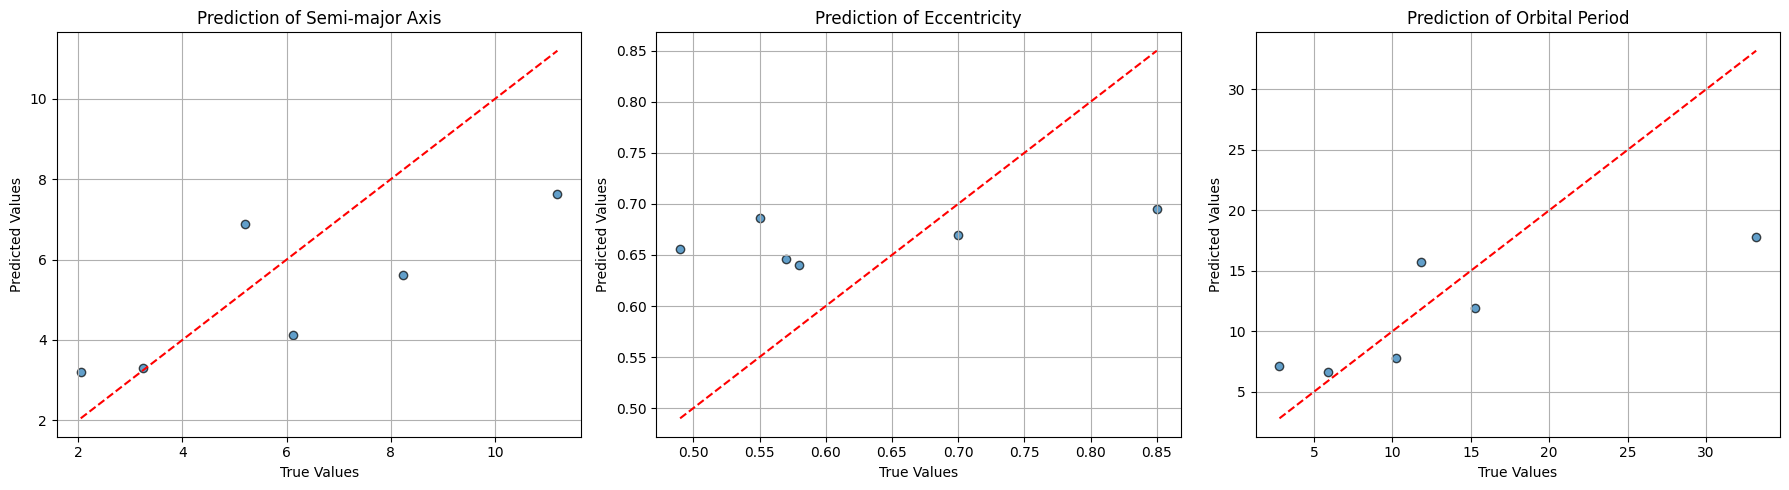

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import copy

# 1. CSV 데이터 로드 및 전처리 함수
def load_and_process_data(csv_path, seq_len=20):
    df = pd.read_csv(csv_path)

    def parse_dates(date_str):
        dates = pd.to_datetime([d.strip() for d in date_str.split(',') if d.strip() != ''])
        return dates.to_series().sort_values()

    X_list = []
    y_list = []
    comet_names = []

    for _, row in df.iterrows():
        try:
            perihelion_dates = parse_dates(row['perihelion_dates'])
            aphelion_dates = parse_dates(row['aphelion_dates'])
            if len(perihelion_dates) < 2 or len(aphelion_dates) < 2:
                print(f"Not enough perihelion/aphelion dates for {row['comet_name']}, skipping.")
                continue

            ts_features = create_time_series_features(perihelion_dates, aphelion_dates, seq_len)
            X_list.append(ts_features)

            target = np.array([
                row['semi_major_axis'],
                row['eccentricity'],
                row['orbital_period']
            ])
            y_list.append(target)
            comet_names.append(row['comet_name'])

        except Exception as e:
            print(f"Error processing {row['comet_name']}: {e}")

    if len(X_list) == 0:
        raise RuntimeError("No data collected. Check CSV content.")

    X = np.array(X_list)
    y = np.array(y_list)
    return X, y, comet_names


# 2. 시계열 특징 생성 함수 (외합, 내합, 회합 주기 근사)
def create_time_series_features(perihelion_dates, aphelion_dates, num_points=20):
    start_date = perihelion_dates.iloc[-1]
    end_date = perihelion_dates.iloc[0] + pd.Timedelta(days=365.25)
    total_days = (end_date - start_date).days

    times = np.linspace(0, total_days, num_points)
    peri_to_aphe_days = (aphelion_dates.iloc[-1] - perihelion_dates.iloc[-1]).days
    ext_period = peri_to_aphe_days
    int_period = peri_to_aphe_days / 2

    feature_1 = times / total_days  # normalized time progression
    feature_2 = np.sin(2 * np.pi * times / ext_period)  # approx aphelion (outer) cycle
    feature_3 = np.cos(2 * np.pi * times / int_period)  # approx perihelion (inner) cycle

    ts_features = np.vstack([feature_1, feature_2, feature_3]).T
    return ts_features

# 3. Dataset 클래스
class CometDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# 4. Positional Encoding
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.pe = pe.unsqueeze(0)
    def forward(self, x):
        seq_len = x.size(1)
        x = x + self.pe[:, :seq_len].to(x.device)
        return x

# 5. Transformer 모델 정의
class TransformerRegressor(nn.Module):
    def __init__(self, input_dim, seq_len, output_dim, nhead=4, num_layers=3, dim_feedforward=128, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, dim_feedforward)
        self.pos_encoder = PositionalEncoding(dim_feedforward, max_len=seq_len)
        encoder_layer = nn.TransformerEncoderLayer(d_model=dim_feedforward, nhead=nhead,
                                                   dim_feedforward=dim_feedforward*2, dropout=dropout)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc_out = nn.Sequential(
            nn.Linear(seq_len * dim_feedforward, 64),
            nn.ReLU(),
            nn.Linear(64, output_dim)
        )
    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_encoder(x)
        x = x.permute(1, 0, 2)  # (seq_len, batch, feature)
        x = self.transformer_encoder(x)
        x = x.permute(1, 0, 2).contiguous()
        x = x.flatten(start_dim=1)
        out = self.fc_out(x)
        return out

# 6. 평가 함수
def evaluate_model(model, dataloader, device='cpu'):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            preds = model(X_batch).cpu().numpy()
            y_pred.append(preds)
            y_true.append(y_batch.numpy())
    y_true = np.vstack(y_true)
    y_pred = np.vstack(y_pred)
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"Evaluation Results - MSE: {mse:.6f}, MAE: {mae:.6f}, R2: {r2:.6f}")
    return y_true, y_pred

# 7. 시각화 함수 (영어 축)
def plot_predictions(y_true, y_pred, feature_names=['Semi-major Axis', 'Eccentricity', 'Orbital Period']):
    num_features = y_true.shape[1]
    plt.figure(figsize=(6 * num_features, 5))
    for i in range(num_features):
        plt.subplot(1, num_features, i + 1)
        plt.scatter(y_true[:, i], y_pred[:, i], alpha=0.7, edgecolors='k')
        plt.plot([y_true[:, i].min(), y_true[:, i].max()],
                 [y_true[:, i].min(), y_true[:, i].max()], 'r--')
        plt.xlabel('True Values')
        plt.ylabel('Predicted Values')
        plt.title(f'Prediction of {feature_names[i]}')
        plt.grid(True)
    plt.tight_layout()
    plt.show()

# === 메인 실행부 ===
if __name__ == "__main__":
    # CSV 파일 경로 입력
    csv_path = 'comet_virtual_dataset_extended.csv'

    # 데이터 로드
    X, y, comet_names = load_and_process_data(csv_path, seq_len=20)

    # 스케일링
    X_reshaped = X.reshape(-1, X.shape[2])
    scaler_X = StandardScaler().fit(X_reshaped)
    X_scaled = scaler_X.transform(X_reshaped).reshape(X.shape)
    scaler_y = StandardScaler().fit(y)
    y_scaled = scaler_y.transform(y)

    # 학습/검증 분리
    X_train, X_val, y_train, y_val = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

    train_dataset = CometDataset(X_train, y_train)
    val_dataset = CometDataset(X_val, y_val)
    train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False)

    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model = TransformerRegressor(input_dim=X.shape[2], seq_len=X.shape[1], output_dim=y.shape[1]).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()

    best_val_loss = float('inf')
    patience = 10
    counter = 0
    num_epochs = 100

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
        train_loss /= len(train_loader.dataset)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item() * X_batch.size(0)
        val_loss /= len(val_loader.dataset)

        print(f"Epoch {epoch+1}: Train Loss={train_loss:.6f}, Val Loss={val_loss:.6f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print("Early stopping triggered")
                break

    model.load_state_dict(best_model_wts)

    # 평가 및 시각화
    y_true_scaled, y_pred_scaled = evaluate_model(model, val_loader, device=device)
    y_true = scaler_y.inverse_transform(y_true_scaled)
    y_pred = scaler_y.inverse_transform(y_pred_scaled)

    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"Original scale - MSE: {mse:.6f}, MAE: {mae:.6f}, R2: {r2:.6f}")

    plot_predictions(y_true, y_pred)


# Try #5

Total data points fetched: 3416
Dataset shapes: X=(3406, 10, 2), y=(3406,)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 10, 2)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 10, 2)     │          4 │ input_layer[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 10, 2)     │         90 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2)         │          0 │ multi_head_atten… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │        192 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         65 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 351 (1.37 KB)

 Trainable params: 351 (1.37 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
149/149 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.9718 - mae: 0.9514 - val_loss: 0.9724 - val_mae: 0.9434
Epoch 2/100
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.9506 - mae: 0.9293 - val_loss: 0.9748 - val_mae: 0.9378
Epoch 3/100
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.9377 - mae: 0.9187 - val_loss: 0.9727 - val_mae: 0.9300
Epoch 4/100
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.9476 - mae: 0.9201 - val_loss: 0.9754 - val_mae: 0.9382
Epoch 5/100
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.9347 - mae: 0.9178 - val_loss: 0.9720 - val_mae: 0.9357
Epoch 6/100
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.9527 - mae: 0.9260 - val_loss: 0.9742 - val_mae: 0.9335
Epoch 7/100
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.9524 - mae: 0.9230 - val_loss: 0.9711 - val_mae: 0.9346
Epoch 8/100
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.9580 - mae: 0.9289 - val_loss: 0.9745 - val_mae: 0.9330
Epoch 9/100
149/149 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/

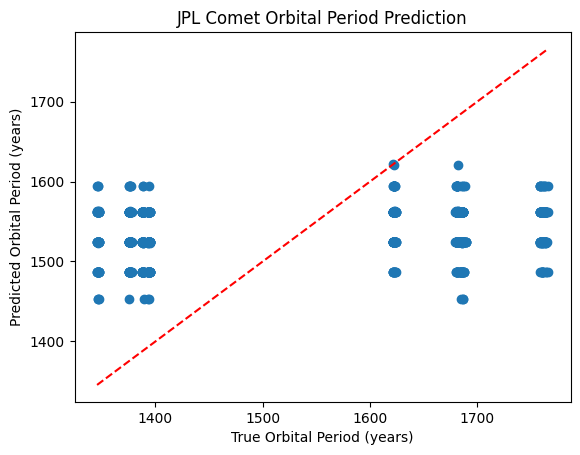

In [ ]:
import numpy as np
import pandas as pd
from astroquery.jplhorizons import Horizons
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# 혜성 목록 (JPL에서 인식 가능한 small-body ID 또는 이름)
comet_ids = [1, 2, 9, 19, 21, 103, 81, 67]


# 기간 (예시로 1990-2025까지)
start_epoch = '1990-01-01'
stop_epoch = '2025-01-01'

def clean_datetime_str(dt_series):
    # 'A.D. ' 접두사 제거
    dt_clean = dt_series.str.replace('A.D. ', '', regex=False)
    # 정확한 포맷 지정해서 변환 (예: '1990-Jan-01 00:00:00.0000')
    return pd.to_datetime(dt_clean, format='%Y-%b-%d %H:%M:%S.%f', errors='coerce')


def fetch_orbital_elements(comet_id, start, stop):
    try:
        obj = Horizons(id=comet_id, location='@sun',
                       epochs={'start':start, 'stop':stop, 'step':'30d'},
                       id_type='smallbody')
        elements = obj.elements()

        # astropy Table -> pandas DataFrame 변환
        elements_df = elements.to_pandas()

        # 날짜 문자열 전처리
        elements_df['datetime_str'] = elements_df['datetime_str'].str.replace('A.D. ', '', regex=False)
        elements_df['datetime_str'] = pd.to_datetime(elements_df['datetime_str'], format='%Y-%b-%d %H:%M:%S.%f', errors='coerce')

        # 필요한 컬럼 필터링
        elements_df = elements_df[['datetime_str', 'a', 'e', 'P']]

        # NaT 값 제거 및 정렬
        elements_df = elements_df.dropna(subset=['datetime_str'])
        elements_df = elements_df.sort_values('datetime_str').reset_index(drop=True)

        return elements_df
    except Exception as e:
        print(f"Error fetching {comet_id}: {e}")
        return None




# 모든 혜성 데이터 가져오기 및 통합
data_list = []
for comet_id in comet_ids:
    df = fetch_orbital_elements(comet_id, start_epoch, stop_epoch)
    if df is not None and len(df) > 5:
        df['comet'] = comet
        data_list.append(df)

if len(data_list) == 0:
    raise RuntimeError("No comet data fetched.")

data_all = pd.concat(data_list, ignore_index=True)
print(f"Total data points fetched: {len(data_all)}")

# --- 시계열 시퀀스 생성 함수 ---
def create_sequences(df, seq_len=10):
    X, y = [], []
    comet_list = df['comet'].unique()
    for comet in comet_list:
        subset = df[df['comet'] == comet].sort_values('datetime_str')
        features = subset[['a', 'e']].values  # 입력 특성: 반장축, 이심률
        targets = subset['P'].values           # 예측 대상: 공전주기

        # 시퀀스 슬라이딩 윈도우 생성
        for i in range(len(features) - seq_len):
            X.append(features[i:i+seq_len])
            y.append(targets[i+seq_len])
    return np.array(X), np.array(y)

SEQ_LEN = 10
X, y = create_sequences(data_all, seq_len=SEQ_LEN)

print(f"Dataset shapes: X={X.shape}, y={y.shape}")

# 데이터 정규화
scaler_X = StandardScaler()
nsamples, nseq, nfeat = X.shape
X_reshaped = X.reshape(-1, nfeat)
X_scaled = scaler_X.fit_transform(X_reshaped).reshape(nsamples, nseq, nfeat)

scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y.reshape(-1,1))

# 학습/검증 분리
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y_scaled, test_size=0.3, random_state=42)

# Transformer 모델 정의
def build_transformer_model(seq_len, feature_dim):
    inputs = layers.Input(shape=(seq_len, feature_dim))
    x = layers.LayerNormalization()(inputs)
    x = layers.MultiHeadAttention(num_heads=4, key_dim=feature_dim)(x, x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    outputs = layers.Dense(1)(x)
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

model = build_transformer_model(SEQ_LEN, nfeat)
model.summary()

# 조기 종료 콜백
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# 모델 학습
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop]
)

# 예측 및 평가
y_pred_scaled = model.predict(X_val)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_val)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print(f"Evaluation Results - MSE: {mse:.6f}, MAE: {mae:.6f}, R2: {r2:.6f}")

# 결과 시각화
plt.scatter(y_true, y_pred)
plt.xlabel('True Orbital Period (years)')
plt.ylabel('Predicted Orbital Period (years)')
plt.title('JPL Comet Orbital Period Prediction')
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
plt.show()
